# VGG16 + SVM (Binary)

## Setup

In [1]:
# ── KAGGLE SETUP: Download ADNI dataset from Google Drive ───────────────

import os, subprocess
from pathlib import Path

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')
ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'

if not os.path.exists(WORK_DIR / 'CN'):
    print('📦 Step 1/3: Installing gdown...')
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    
    print('⬇️  Step 2/3: Downloading ADNI dataset from Google Drive...')
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    
    print('📂 Step 3/3: Extracting ADNI Dataset...')
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink()
    print('✅ Done! ADNI Dataset ready.')

ADNI_DIR = str(WORK_DIR)
for root, dirs, files in os.walk(WORK_DIR):
    if 'CN' in dirs and 'MCI' in dirs and 'AD' in dirs:
        ADNI_DIR = root
        break

KAGGLE_DIR = '/kaggle/input'
for root, dirs, files in os.walk('/kaggle/input'):
    if 'MildDemented' in dirs and 'ModerateDemented' in dirs:
        KAGGLE_DIR = root
        break

print(f"\nADNI_DIR = {ADNI_DIR}")
print(f"KAGGLE_DIR = {KAGGLE_DIR}")

📦 Step 1/3: Installing gdown...
⬇️  Step 2/3: Downloading ADNI dataset from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz
From (redirected): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz&confirm=t&uuid=88eb7713-4c6a-4bb4-b9e8-845a6cd9396d
To: /kaggle/working/adni_dataset.zip
100%|██████████| 387M/387M [00:06<00:00, 56.8MB/s] 


📂 Step 3/3: Extracting ADNI Dataset...
✅ Done! ADNI Dataset ready.

ADNI_DIR = /kaggle/working/adni_nifti_preprocessed
KAGGLE_DIR = /kaggle/input


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

## 1. Subject-Level Splitting & Dataset Definition


In [3]:
def get_adni_subject_splits(adni_dir, train_ratio=0.7, val_ratio=0.15):
    subjects = []
    labels = []
    for class_name in ['CN', 'MCI', 'AD']:
        class_dir = os.path.join(adni_dir, class_name)
        if not os.path.exists(class_dir): continue
        for subj_id in os.listdir(class_dir):
            if os.path.isdir(os.path.join(class_dir, subj_id)):
                subjects.append((subj_id, class_name))
                labels.append(class_name)
    from collections import defaultdict
    class_subjs = defaultdict(list)
    for s, l in subjects: class_subjs[l].append(s)
    
    train_subjs, val_subjs, test_subjs = set(), set(), set()
    for c, subjs in class_subjs.items():
        random.shuffle(subjs)
        n = len(subjs)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        train_subjs.update(subjs[:n_train])
        val_subjs.update(subjs[n_train:n_train+n_val])
        test_subjs.update(subjs[n_train+n_val:])
    return train_subjs, val_subjs, test_subjs

train_subjs, val_subjs, test_subjs = get_adni_subject_splits(ADNI_DIR)
print(f"ADNI Subjects - Train: {len(train_subjs)}, Val: {len(val_subjs)}, Test: {len(test_subjs)}")

ADNI Subjects - Train: 222, Val: 47, Test: 51


In [4]:
class BinaryAlzheimerDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
    def __len__(self): return len(self.data_list)
    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 2. Universal Feature Extraction & SVM Training (Paper Reproduction)


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

def extract_features(loader, model):
    model.eval()
    features = []
    labels_list = []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extracting Features"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            features.extend(outputs.cpu().numpy())
            labels_list.extend(labels.numpy())
    return np.array(features), np.array(labels_list)

def run_svm_pipeline(class_0_name, class_1_name, model_type='vgg16'):
    print(f"\n{'='*50}")
    print(f"🚀 STARTING SVM PIPELINE: {class_0_name} vs {class_1_name} using {model_type.upper()}")
    print(f"{'='*50}")
    
    train_data, val_data, test_data = [], [], []
    class_map = {class_0_name: 0, class_1_name: 1}
    
    for c in [class_0_name, class_1_name]:
        c_dir = os.path.join(ADNI_DIR, c)
        if not os.path.exists(c_dir): continue
        for subj_id in os.listdir(c_dir):
            subj_dir = os.path.join(c_dir, subj_id)
            if not os.path.isdir(subj_dir): continue
            imgs = [os.path.join(subj_dir, img) for img in os.listdir(subj_dir) if img.endswith('.png')]
            for img in imgs:
                item = (img, class_map[c])
                if subj_id in train_subjs: train_data.append(item)
                elif subj_id in val_subjs: val_data.append(item)
                elif subj_id in test_subjs: test_data.append(item)
                
    train_loader = DataLoader(BinaryAlzheimerDataset(train_data, train_transform), batch_size=32, shuffle=False)
    val_loader = DataLoader(BinaryAlzheimerDataset(val_data, val_transform), batch_size=32, shuffle=False)
    test_loader = DataLoader(BinaryAlzheimerDataset(test_data, val_transform), batch_size=32, shuffle=False)
    
    if model_type == 'vgg19':
        base_model = models.vgg19(pretrained=True)
    else:
        base_model = models.vgg16(pretrained=True)
        
    for param in base_model.parameters():
        param.requires_grad = False
        
    base_model.classifier = nn.Sequential(
        base_model.classifier[0],
        base_model.classifier[1]
    )
    base_model = base_model.to(device)
    
    print(f"Extracting Train Features (10x Augmentation Loop)...")
    X_train_list, y_train_list = [], []
    AUGMENT_FACTOR = 10
    for i in range(AUGMENT_FACTOR):
        print(f"Augmentation Pass {i+1}/{AUGMENT_FACTOR}...")
        X, y = extract_features(train_loader, base_model)
        X_train_list.append(X)
        y_train_list.append(y)
        
    X_train = np.vstack(X_train_list)
    y_train = np.concatenate(y_train_list)
    
    print(f"Extracting Val Features (1x No Augmentation)...")
    X_val, y_val = extract_features(val_loader, base_model)
    print(f"Extracting Test Features (1x No Augmentation)...")
    X_test, y_test = extract_features(test_loader, base_model)
    
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])
    
    print(f"Standardizing Features...")
    scaler = StandardScaler()
    X_train_full = scaler.fit_transform(X_train_full)
    X_test = scaler.transform(X_test)
    
    print(f"Training RBF SVM (C=10, gamma='scale')...")
    svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42)
    svm.fit(X_train_full, y_train_full)
    
    print(f"\n🧪 Evaluating {class_0_name} vs {class_1_name} on Unseen Test Subjects...")
    test_preds = svm.predict(X_test)
    
    print(classification_report(y_test, test_preds, target_names=[class_0_name, class_1_name]))
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[class_0_name, class_1_name], yticklabels=[class_0_name, class_1_name])
    plt.title(f"{class_0_name} vs {class_1_name} (SVM Test Set)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

## 3. Execute Binary Tasks
As per the paper:
* **MCI vs AD**: VGG19 FC6 + SVM
* **AD vs CN**: VGG16 FC6 + SVM
* **MCI vs CN**: VGG16 FC6 + SVM



🚀 STARTING SVM PIPELINE: MCI vs AD using VGG19


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 223MB/s] 


Extracting Train Features (10x Augmentation Loop)...
Augmentation Pass 1/10...


...

Extracting Val Features (1x No Augmentation)...


Extracting Features: 100%|██████████| 29/29 [00:07<00:00,  3.94it/s]


Extracting Test Features (1x No Augmentation)...


Extracting Features: 100%|██████████| 31/31 [00:07<00:00,  3.98it/s]


Standardizing Features...
Training RBF SVM (C=10, gamma='scale')...

🧪 Evaluating MCI vs AD on Unseen Test Subjects...
              precision    recall  f1-score   support

         MCI       0.78      0.92      0.84       734
          AD       0.41      0.17      0.24       234

    accuracy                           0.74       968
   macro avg       0.59      0.55      0.54       968
weighted avg       0.69      0.74      0.70       968



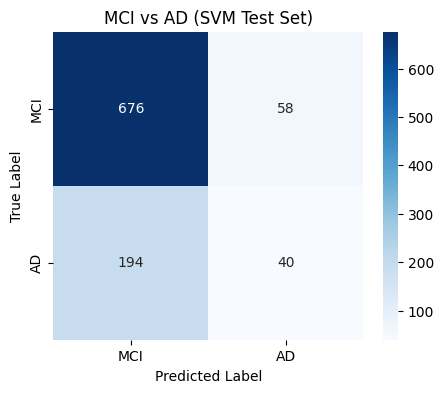

In [6]:
run_svm_pipeline('MCI', 'AD', model_type='vgg19')


🚀 STARTING SVM PIPELINE: AD vs CN using VGG16


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 185MB/s] 


Extracting Train Features (10x Augmentation Loop)...
Augmentation Pass 1/10...


...

Extracting Val Features (1x No Augmentation)...


Extracting Features: 100%|██████████| 18/18 [00:03<00:00,  4.62it/s]


Extracting Test Features (1x No Augmentation)...


Extracting Features: 100%|██████████| 19/19 [00:04<00:00,  4.50it/s]


Standardizing Features...
Training RBF SVM (C=10, gamma='scale')...

🧪 Evaluating AD vs CN on Unseen Test Subjects...
              precision    recall  f1-score   support

          AD       0.56      0.49      0.52       234
          CN       0.70      0.75      0.73       374

    accuracy                           0.65       608
   macro avg       0.63      0.62      0.62       608
weighted avg       0.65      0.65      0.65       608



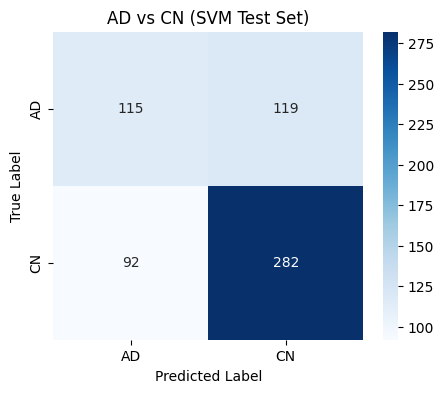

In [7]:
run_svm_pipeline('AD', 'CN', model_type='vgg16')


🚀 STARTING SVM PIPELINE: MCI vs CN using VGG16


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extracting Train Features (10x Augmentation Loop)...
Augmentation Pass 1/10...


Extracting Features: 100%|██████████| 155/155 [00:36<00:00,  4.23it/s]


Augmentation Pass 2/10...


...

Extracting Val Features (1x No Augmentation)...


Extracting Features: 100%|██████████| 33/33 [00:07<00:00,  4.57it/s]


Extracting Test Features (1x No Augmentation)...


Extracting Features: 100%|██████████| 35/35 [00:07<00:00,  4.51it/s]


Standardizing Features...
Training RBF SVM (C=10, gamma='scale')...

🧪 Evaluating MCI vs CN on Unseen Test Subjects...
              precision    recall  f1-score   support

         MCI       0.67      0.86      0.76       734
          CN       0.40      0.18      0.24       374

    accuracy                           0.63      1108
   macro avg       0.54      0.52      0.50      1108
weighted avg       0.58      0.63      0.58      1108



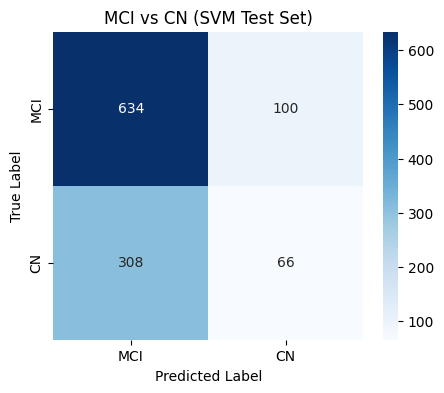

In [8]:
run_svm_pipeline('MCI', 'CN', model_type='vgg16')

## 4. Explainable AI on the VGG-16 → SVM Pipeline

The SVM consumes the FC6 (4096-dim) features extracted from VGG-16. We therefore explain the pipeline at two levels: (a) the *image* level via Grad-CAM/LIME/SHAP on a wrapper that chains VGG-features → SVM-score, and (b) the *feature* level via permutation-importance over the FC6 features.

Below we re-run a minimal version of the pipeline (AD vs CN) so the explainability section is fully self-contained.

In [ ]:
!pip install grad-cam lime shap -q

In [ ]:
import os, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt, cv2
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import models, transforms
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

XAI_CLASS_0, XAI_CLASS_1 = 'CN', 'AD'
XAI_LABELS = [XAI_CLASS_0, XAI_CLASS_1]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

_xai_val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def _xai_collect(class_0, class_1):
    train_data, val_data, test_data = [], [], []
    cmap = {class_0: 0, class_1: 1}
    for c in [class_0, class_1]:
        cdir = os.path.join(ADNI_DIR, c)
        if not os.path.exists(cdir): continue
        for subj_id in os.listdir(cdir):
            sdir = os.path.join(cdir, subj_id)
            if not os.path.isdir(sdir): continue
            imgs = [os.path.join(sdir, im) for im in os.listdir(sdir) if im.endswith('.png')]
            for im in imgs:
                item = (im, cmap[c])
                if subj_id in train_subjs:     train_data.append(item)
                elif subj_id in val_subjs:     val_data.append(item)
                elif subj_id in test_subjs:    test_data.append(item)
    return train_data, val_data, test_data

xai_train, xai_val, xai_test = _xai_collect(XAI_CLASS_0, XAI_CLASS_1)
xai_train_loader = DataLoader(BinaryAlzheimerDataset(xai_train + xai_val, _xai_val_tf),
                              batch_size=32, shuffle=False)
xai_test_loader  = DataLoader(BinaryAlzheimerDataset(xai_test, _xai_val_tf),
                              batch_size=32, shuffle=False)
print(f'XAI dataset (test set): {len(xai_test)} images for {XAI_CLASS_0} vs {XAI_CLASS_1}')

vgg16 = models.vgg16(pretrained=True)
for p in vgg16.parameters(): p.requires_grad = False
vgg16_fc6 = nn.Sequential(vgg16.classifier[0], vgg16.classifier[1])
vgg16_feat = nn.Sequential(
    vgg16.features, vgg16.avgpool, nn.Flatten(), vgg16_fc6
).to(device).eval()

@torch.no_grad()
def _xai_extract(loader):
    feats, lbls = [], []
    for x, y in loader:
        feats.append(vgg16_feat(x.to(device)).cpu().numpy()); lbls.append(y.numpy())
    return np.vstack(feats), np.concatenate(lbls)

X_train_xai, y_train_xai = _xai_extract(xai_train_loader)
X_test_xai,  y_test_xai  = _xai_extract(xai_test_loader)
xai_scaler = StandardScaler().fit(X_train_xai)
X_train_xai_s = xai_scaler.transform(X_train_xai)
X_test_xai_s  = xai_scaler.transform(X_test_xai)
xai_svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
              probability=True, random_state=42).fit(X_train_xai_s, y_train_xai)
print('Mini SVM ready. Test acc:', xai_svm.score(X_test_xai_s, y_test_xai))


### 4.1 Grad-CAM on the VGG-16 backbone

We attach Grad-CAM to the last conv block of VGG-16. The CAM is driven by a *probe head* (a fresh logistic layer fit on the FC6 features) so that gradients flow end-to-end from a class score back to the conv feature maps. This visualises which brain regions VGG-16 highlights for the SVM-predicted class.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.linear_model import LogisticRegression

probe = LogisticRegression(max_iter=2000, class_weight='balanced')
probe.fit(X_train_xai_s, y_train_xai)
probe_W = torch.tensor(probe.coef_, dtype=torch.float32, device=device)
probe_b = torch.tensor(probe.intercept_, dtype=torch.float32, device=device)
scaler_mean = torch.tensor(xai_scaler.mean_, dtype=torch.float32, device=device)
scaler_scale = torch.tensor(xai_scaler.scale_, dtype=torch.float32, device=device)

class VGG16ProbeHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = vgg16.features
        self.avgpool  = vgg16.avgpool
        self.fc6      = vgg16_fc6
    def forward(self, x):
        f = self.fc6(torch.flatten(self.avgpool(self.features(x)), 1))
        f = (f - scaler_mean) / (scaler_scale + 1e-8)
        logit = f @ probe_W.t() + probe_b
        return torch.cat([-logit, logit], dim=1)

cam_model = VGG16ProbeHead().to(device).eval()
for p in cam_model.parameters(): p.requires_grad = True
cam = GradCAM(model=cam_model, target_layers=[cam_model.features[-1]])

xai_pick = {}
for path, lbl in xai_test:
    if lbl not in xai_pick:
        xai_pick[lbl] = path
    if len(xai_pick) == 2: break

def _xai_to_tensor(path):
    img = Image.open(path).convert('RGB')
    return _xai_val_tf(img).unsqueeze(0).to(device), np.array(img.resize((224, 224))) / 255.0

for lbl, path in sorted(xai_pick.items()):
    img_t, img_rgb = _xai_to_tensor(path)
    grayscale = cam(input_tensor=img_t, targets=[ClassifierOutputTarget(lbl)])[0]
    heat = cv2.applyColorMap((grayscale * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB) / 255.0
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    ax[0].imshow(img_rgb); ax[0].set_title(f'Input ({XAI_LABELS[lbl]})'); ax[0].axis('off')
    ax[1].imshow(grayscale, cmap='hot'); ax[1].set_title('Grad-CAM'); ax[1].axis('off')
    ax[2].imshow(0.5 * img_rgb + 0.5 * heat); ax[2].set_title('Overlay'); ax[2].axis('off')
    plt.suptitle(f'Grad-CAM (VGG-16 features) — {XAI_LABELS[lbl]}'); plt.tight_layout(); plt.show()


### 4.2 LIME on the VGG-16 → SVM pipeline

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_predict_svm(images_np):
    imgs = torch.from_numpy(images_np).float().permute(0, 3, 1, 2).to(device)
    mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
    std  = torch.tensor(IMAGENET_STD,  device=device).view(1, 3, 1, 1)
    imgs = (imgs - mean) / std
    with torch.no_grad():
        feats = vgg16_feat(imgs).cpu().numpy()
    feats = xai_scaler.transform(feats)
    return xai_svm.predict_proba(feats)

lime_explainer = lime_image.LimeImageExplainer()
for lbl, path in sorted(xai_pick.items()):
    _, img_rgb = _xai_to_tensor(path)
    explanation = lime_explainer.explain_instance(
        image=img_rgb.astype(np.double), classifier_fn=lime_predict_svm,
        labels=[lbl], num_samples=400
    )
    img, mask = explanation.get_image_and_mask(
        label=lbl, positive_only=False, num_features=8, hide_rest=False
    )
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    ax[0].imshow(img_rgb); ax[0].set_title(f'Input ({XAI_LABELS[lbl]})'); ax[0].axis('off')
    ax[1].imshow(mark_boundaries(img, mask)); ax[1].set_title('LIME'); ax[1].axis('off')
    plt.suptitle(f'LIME (VGG-16 → SVM) — {XAI_LABELS[lbl]}'); plt.tight_layout(); plt.show()


### 4.3 SHAP (KernelExplainer over a low-dim PCA of FC6)

Because FC6 is 4096-dim, we project it onto its top-32 principal components and explain the SVM in that compressed space with `shap.KernelExplainer`. This gives per-component Shapley values for the test samples.

In [ ]:
import shap
from sklearn.decomposition import PCA

pca = PCA(n_components=32, random_state=42).fit(X_train_xai_s)
X_train_pca = pca.transform(X_train_xai_s)
X_test_pca  = pca.transform(X_test_xai_s)
svm_pca = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
              probability=True, random_state=42).fit(X_train_pca, y_train_xai)
print('PCA-SVM test acc:', svm_pca.score(X_test_pca, y_test_xai))

bg = shap.sample(X_train_pca, 50, random_state=0)
kshap = shap.KernelExplainer(svm_pca.predict_proba, bg)
shap_values = kshap.shap_values(X_test_pca[:25], nsamples=100)
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X_test_pca[:25], feature_names=[f'PC{i+1}' for i in range(32)],
                  plot_type='bar', show=False)
plt.title(f'SHAP — PCA(FC6) feature importance for {XAI_LABELS[1]} class')
plt.tight_layout(); plt.show()


### 4.4 Permutation Importance on the FC6 features (top-k)

We shuffle each of the top-k most-variant FC6 components on the test set and measure how much SVM accuracy drops. Components whose permutation destroys accuracy are the ones the SVM truly depends on.

In [ ]:
top_k = 64
var = X_train_xai_s.var(axis=0)
top_idx = np.argsort(var)[-top_k:]

class _FC6Slice:
    def __init__(self, full_svm, idx, n_features):
        self.svm = full_svm; self.idx = idx; self.n = n_features
    def predict(self, X_partial):
        X_full = np.zeros((X_partial.shape[0], self.n), dtype=X_partial.dtype)
        X_full[:, self.idx] = X_partial
        return self.svm.predict(X_full)
    def score(self, X_partial, y):
        return float((self.predict(X_partial) == y).mean())

slice_model = _FC6Slice(xai_svm, top_idx, X_test_xai_s.shape[1])
result = permutation_importance(
    slice_model, X_test_xai_s[:, top_idx], y_test_xai,
    n_repeats=5, random_state=42, n_jobs=1
)
order = np.argsort(result.importances_mean)[::-1][:20]
plt.figure(figsize=(8, 5))
plt.barh([f'FC6[{top_idx[i]}]' for i in order][::-1],
         result.importances_mean[order][::-1],
         xerr=result.importances_std[order][::-1])
plt.xlabel('Drop in test accuracy when permuted')
plt.title(f'Permutation importance — top FC6 features ({XAI_CLASS_0} vs {XAI_CLASS_1})')
plt.tight_layout(); plt.show()
